# Backtesting a Simple Trading Strategy Using Python
Stock- NASDAQ: AMD, Timeframe: 4 yrs 7 months 30 days (1703 days)

Hello all! I have backtested a simple trading strategy using historical stock prices of AMD (NASDAQ: AMD) over a time frame of 1703 days (2021-01-01 to 2025-08-31). The time window for moving average is 100 days which suited the most (justification at the end). I've used yfinance, pandas, numpy ,plotly and matplotlib libraries for this code. I worked with real stock price data downloaded from yfinance, generated a trading signal which signified an order (long or short). Over a period of 1703 days, my strategy achieved a net profit of 157.57% which accounts to a CAGR of almost 25.28% in contrast to stocks actual price climbing by just 67.9% (simpler words, someone holding the stock long from 2021-01-01 to 2025-08-31 would have suffered a net profit of 67.9% whereas my strategy generated a profit of 157.57% in the same time).


I've also uploaded the model on GitHub for easy accessibility and future improvements. You can find it here: https://github.com/rissin-bits/Backtest_SMA_Strategy

In [ ]:
#installing and importing the required libraries

!pip install yfinance
import yfinance as yf
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt

#Downloading Stock Data

In [ ]:
stock = "AMD"
start_date = "2021-01-01"
end_date = "2025-08-31"

data=yf.download(stock,start_date,end_date)
data.columns = data.columns.droplevel(1) #yfinance returns a dataframe whoses second row is AMD AMD AMD AMD below all our data points. so it removes that datapoint

print(data.head())

/tmp/ipython-input-3165390949.py:5: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed

Price           Close       High        Low       Open    Volume
Date                                                            
2021-01-04  92.300003  96.059998  90.919998  92.110001  51802600
2021-01-05  92.769997  93.209999  91.410004  92.099998  34208000
2021-01-06  90.330002  92.279999  89.459999  91.620003  51911700
2021-01-07  95.160004  95.510002  91.199997  91.330002  42897200
2021-01-08  94.580002  96.400002  93.269997  95.980003  39816400


# Interactive Price Chart
I've used plotly for a better and interactivce dynamic graph to cross check  prices. Matplotib can also be used for the same but it will return static graphs.

In [ ]:
fig = px.line(data, x=data.index, y="Close", title=f"{stock} Stock Price", labels={"x": "Date", "Close": "Price in USD"})
fig.update_layout(width=1800, height=900, legend=dict(title=""),xaxis_title="Date",yaxis_title="Price in USD",template="plotly_white")
fig.show()

# Calculating 100D Moving Average

In [ ]:
data["100d_MA"] = data["Close"].rolling(window=100).mean() ##rolling window is a pandas method which takes up past 99 (99+1) day data and .mean() takes out the mean
data_final=data[["Close", "High", "Low", "Open", "Volume", "100d_MA"]]
data_final = data_final.iloc[99:] #drops first 99 rows as they don't have a 100d ma
print(data_final.head(300))

Price           Close        High        Low       Open     Volume  100d_MA
Date                                                                       
2021-05-26  78.339996   78.589996  77.589996  77.830002   30354000  83.5198
2021-05-27  78.419998   78.430000  77.470001  78.110001   35883200  83.3810
2021-05-28  80.080002   81.089996  78.660004  78.660004   40952700  83.2541
2021-06-01  80.809998   82.910004  80.660004  81.010002   43433000  83.1589
2021-06-02  81.970001   82.599998  80.660004  81.000000   35203200  83.0270
...               ...         ...        ...        ...        ...      ...
2022-07-28  91.669998   92.220001  88.589996  90.419998   79009200  95.0641
2022-07-29  94.470001   94.809998  90.559998  90.699997   76630700  94.9793
2022-08-01  96.779999   98.389999  93.959999  95.589996   96477500  94.8918
2022-08-02  99.290001  100.919998  95.360001  95.709999  116734100  94.7742
2022-08-03  98.089996   98.769997  93.620003  94.830002  131142000  94.6905

[300 rows x

# Interactive Graph with Price vs 100D Moving Average

In [ ]:
fig = px.line(data_final, x=data_final.index, y=["Close", "100d_MA"], title=f"{stock} Price vs 100D Moving average", width=1800, height=900)
fig.show()

# Generating Trading Signals

In [ ]:
import numpy as np
data_final = data_final.reset_index() #converts the index date into a normal column date which can be easily used for adding new columns
signal = data_final[["Date", "Close", "100d_MA"]].copy()
signal["Signal"] = np.where(signal["Close"] > signal["100d_MA"], +1, -1)

with pd.option_context("display.max_rows", None, "display.max_columns", None): #displaying whole dataframe to check accuracy
  print(signal)

Price       Date       Close     100d_MA  Signal
0     2021-05-26   78.339996   83.519800      -1
1     2021-05-27   78.419998   83.381000      -1
2     2021-05-28   80.080002   83.254100      -1
3     2021-06-01   80.809998   83.158900      -1
4     2021-06-02   81.970001   83.027000      -1
5     2021-06-03   80.279999   82.884000      -1
6     2021-06-04   81.580002   82.727300      -1
7     2021-06-07   81.349998   82.587200      -1
8     2021-06-08   80.889999   82.478300      -1
9     2021-06-09   79.959999   82.370000      -1
10    2021-06-10   81.559998   82.303500      -1
11    2021-06-11   81.309998   82.222100      -1
12    2021-06-14   81.550003   82.150100      -1
13    2021-06-15   80.470001   82.039500      -1
14    2021-06-16   80.110001   81.912700      -1
15    2021-06-17   84.559998   81.817000       1
16    2021-06-18   84.650002   81.716400       1
17    2021-06-21   82.589996   81.653900       1
18    2021-06-22   83.580002   81.614500       1
19    2021-06-23   8

In [ ]:
#create crossover column with default "hold"
signal["Crossover"] = "hold"

#finding where signal changes (difference is not equal to 0)
signal["Signal_Change"] = signal["Signal"].diff() #calculates difference between current row and previous rows

#bullish crossover when -1 to +1
signal.loc[signal["Signal_Change"] == 2, "Crossover"] = "bullish"

#bearish crossover when +1 to -1
signal.loc[signal["Signal_Change"] == -2, "Crossover"] = "bearish"

#shift by 1 day to avoid look-ahead bias
signal["Crossover"] = signal["Crossover"].shift(1).fillna("hold")

#dropping the intermediate column we made
signal = signal.drop(columns=["Signal_Change"])
signal.loc[signal.index[-1], "Crossover"] = "close" #closing the open trades at last
with pd.option_context("display.max_rows", None, "display.max_columns", None):
    print(signal)

Price       Date       Close     100d_MA  Signal Crossover
0     2021-05-26   78.339996   83.519800      -1      hold
1     2021-05-27   78.419998   83.381000      -1      hold
2     2021-05-28   80.080002   83.254100      -1      hold
3     2021-06-01   80.809998   83.158900      -1      hold
4     2021-06-02   81.970001   83.027000      -1      hold
5     2021-06-03   80.279999   82.884000      -1      hold
6     2021-06-04   81.580002   82.727300      -1      hold
7     2021-06-07   81.349998   82.587200      -1      hold
8     2021-06-08   80.889999   82.478300      -1      hold
9     2021-06-09   79.959999   82.370000      -1      hold
10    2021-06-10   81.559998   82.303500      -1      hold
11    2021-06-11   81.309998   82.222100      -1      hold
12    2021-06-14   81.550003   82.150100      -1      hold
13    2021-06-15   80.470001   82.039500      -1      hold
14    2021-06-16   80.110001   81.912700      -1      hold
15    2021-06-17   84.559998   81.817000       1      ho

# Interactive Chart with Entry and Exit Points

In [ ]:
import plotly.express as px
import plotly.graph_objects as go

#base price chart
fig = go.Figure() #used to define plotly figure object
fig.add_trace(go.Scatter(x=signal["Date"], y=signal["Close"], mode="lines", name="Closing Price", line=dict(color="blue")))
fig.add_trace(go.Scatter(x=signal["Date"], y=signal["100d_MA"], mode="lines", name="100-Day MA", line=dict(color="red")))

#bullish crossover points
bullish_points = signal[signal["Crossover"] == "bullish"]
fig.add_trace(go.Scatter(x=bullish_points["Date"], y=bullish_points["Close"], mode="markers", name="Bullish Crossover", marker=dict(symbol="triangle-up", color="green", size=12)))

#bearish crossover points
bearish_points = signal[signal["Crossover"] == "bearish"]
fig.add_trace(go.Scatter(x=bearish_points["Date"], y=bearish_points["Close"], mode="markers", name="Bearish Crossover", marker=dict(symbol="triangle-down", color="red", size=12)))

#final chart
fig.update_layout(title=f"{stock} Closing Price with Bullish/Bearish Crossovers", xaxis_title="Date", yaxis_title="Price", width=1800, height=900, template="plotly_white")

fig.show()

In [ ]:
#now, removing data with signal=hold because we only need entry/exit points
trades = signal[signal["Crossover"] != "hold"].reset_index(drop=True)
with pd.option_context("display.max_rows", None, "display.max_columns", None):
  print (trades)


Price       Date       Close     100d_MA  Signal Crossover
0     2021-06-18   84.650002   81.716400       1   bullish
1     2022-01-21  118.809998  128.056000      -1   bearish
2     2022-02-10  125.769997  129.655200      -1   bullish
3     2022-02-11  113.180000  129.758800      -1   bearish
4     2022-06-03  106.300003  107.822200      -1   bullish
5     2022-06-06  105.650002  107.505600      -1   bearish
6     2022-08-02   99.290001   94.774200       1   bullish
7     2022-08-29   88.489998   91.808800      -1   bearish
8     2022-12-01   77.480003   77.191700       1   bullish
9     2022-12-05   73.620003   77.116500      -1   bearish
10    2023-01-13   71.000000   69.680700       1   bullish
11    2023-01-20   70.070000   68.743900       1   bearish
12    2023-01-23   76.529999   68.624300       1   bullish
13    2023-08-18  105.449997  106.627800      -1   bearish
14    2023-08-22  105.660004  106.860100      -1   bullish
15    2023-08-23  109.430000  106.975600       1   beari

# Implementing Stop Loss, Justifying Trades and Pnl

In [ ]:
stop_loss_pct = 0.04  #4% stop loss implemented
trade_log = []
capital = 100000
cumulative_pnl = 0
trade_no = 1
open_trade = None  #(entry_price, entry_date, action)

for i, row in signal.iterrows():
    crossover = row["Crossover"]
    date = row["Date"]
    price = row["Close"]

    if open_trade is not None:
        entry_price, entry_date, action = open_trade
        stop_hit = False #a marker that stop loss isn't hit yet

        #check stop loss for long
        if action == "long" and price <= entry_price * (1 - stop_loss_pct):
            stop_hit = True
        #check stop loss for short
        elif action == "short" and price >= entry_price * (1 + stop_loss_pct):
            stop_hit = True

        if stop_hit:
            #close trade immediately
            if action == "long":
                pnl_pct = (price - entry_price) / entry_price * 100
            else:
                pnl_pct = (entry_price - price) / entry_price * 100

            cumulative_pnl += pnl_pct
            capital = capital * (1 + pnl_pct / 100)

            trade_log.append([trade_no, entry_date, entry_price, date, price, action, round(pnl_pct, 2), round(cumulative_pnl, 2), round(capital, 2), "Stop Loss"]) #record for stop-loss exit trade
            trade_no += 1
            open_trade = None
            continue  #skip to next day

    #if crossover signal appears (bullish, bearish, close)
    if crossover in ["bullish", "bearish", "close"]:
        if open_trade is not None:
            entry_price, entry_date, action = open_trade

            if action == "long":
                pnl_pct = (price - entry_price) / entry_price * 100
            else:
                pnl_pct = (entry_price - price) / entry_price * 100

            cumulative_pnl += pnl_pct
            capital = capital * (1 + pnl_pct / 100)

            trade_log.append([trade_no, entry_date, entry_price, date, price, action, round(pnl_pct, 2), round(cumulative_pnl, 2), round(capital, 2), "Normal Exit"]) #record for normal exit trade
            trade_no += 1
            open_trade = None

        if crossover == "bullish":
            open_trade = (price, date, "long")
        elif crossover == "bearish":
            open_trade = (price, date, "short")

trade_log_df = pd.DataFrame(trade_log, columns=["Trade No", "Entry Date", "Entry Price", "Exit Date", "Exit Price", "Action", "PnL %", "Cumulative PnL %", "Capital", "Exit Reason"])

print(trade_log_df)


    Trade No Entry Date  Entry Price  Exit Date  Exit Price Action  PnL %  \
0          1 2021-06-18    84.650002 2022-01-21  118.809998   long  40.35   
1          2 2022-01-21   118.809998 2022-02-04  123.599998  short  -4.03   
2          3 2022-02-10   125.769997 2022-02-11  113.180000   long -10.01   
3          4 2022-06-03   106.300003 2022-06-06  105.650002   long  -0.61   
4          5 2022-06-06   105.650002 2022-08-02   99.290001  short   6.02   
5          6 2022-08-02    99.290001 2022-08-22   92.839996   long  -6.50   
6          7 2022-08-29    88.489998 2022-12-01   77.480003  short  12.44   
7          8 2022-12-01    77.480003 2022-12-05   73.620003   long  -4.98   
8          9 2023-01-13    71.000000 2023-01-19   67.709999   long  -4.63   
9         10 2023-01-20    70.070000 2023-01-23   76.529999  short  -9.22   
10        11 2023-08-18   105.449997 2023-08-22  105.660004  short  -0.20   
11        12 2023-08-22   105.660004 2023-08-23  109.430000   long   3.57   

# Trade Log and Cummulative PnL

In [ ]:
with pd.option_context("display.max_rows", None, "display.max_columns", None):
    print(trade_log_df)

    Trade No Entry Date  Entry Price  Exit Date  Exit Price Action  PnL %  \
0          1 2021-06-18    84.650002 2022-01-21  118.809998   long  40.35   
1          2 2022-01-21   118.809998 2022-02-04  123.599998  short  -4.03   
2          3 2022-02-10   125.769997 2022-02-11  113.180000   long -10.01   
3          4 2022-06-03   106.300003 2022-06-06  105.650002   long  -0.61   
4          5 2022-06-06   105.650002 2022-08-02   99.290001  short   6.02   
5          6 2022-08-02    99.290001 2022-08-22   92.839996   long  -6.50   
6          7 2022-08-29    88.489998 2022-12-01   77.480003  short  12.44   
7          8 2022-12-01    77.480003 2022-12-05   73.620003   long  -4.98   
8          9 2023-01-13    71.000000 2023-01-19   67.709999   long  -4.63   
9         10 2023-01-20    70.070000 2023-01-23   76.529999  short  -9.22   
10        11 2023-08-18   105.449997 2023-08-22  105.660004  short  -0.20   
11        12 2023-08-22   105.660004 2023-08-23  109.430000   long   3.57   

# Performance Metrics of the strategy

In [ ]:
initial_capital = 100000
final_capital = trade_log_df["Capital"].iloc[-1]
total_return_pct = (final_capital / initial_capital - 1) * 100

#calculating years between first and last trade
days = (trade_log_df["Exit Date"].iloc[-1] - trade_log_df["Entry Date"].iloc[0]).days
years = days / 365.25
cagr = ((final_capital / initial_capital) ** (1 / years) - 1) * 100

#max drawdown
capital_series = trade_log_df["Capital"]
rolling_max = capital_series.cummax() #finds cummulative maximum value of capital
drawdown = (capital_series - rolling_max) / rolling_max#calculates drawdown after each peak
max_drawdown = drawdown.min() * 100 #min because it's in negative

#sharpe ratio
signal["Position"] = signal["Signal"].shift(1).fillna(0)   #yesterday’s signal=today’s position
signal["Daily Return"] = signal["Close"].pct_change() * signal["Position"]
mean_daily_return = signal["Daily Return"].mean()
std_daily_return = signal["Daily Return"].std() #sharpe=avg daily return /avg daily volatility (std deviation)*root 252
sharpe_ratio = (mean_daily_return / std_daily_return) * np.sqrt(252)   #sqrt 252 because almost 252 trading days in a financial year (us markets) and the last if statement to avoid division by zero

#cagr calculation
start_date = trade_log_df["Entry Date"].iloc[0]
end_date = trade_log_df["Exit Date"].iloc[-1]
stock_data = yf.download(stock, start=start_date, end=end_date)
stock_start = stock_data["Close"].iloc[0].item()
stock_end = stock_data["Close"].iloc[-1].item()

stock_cagr = ((stock_end / stock_start) ** (1 / years) - 1) * 100

#finding alpha
alpha = cagr - stock_cagr

print("\n-------PERFORMANCE SUMMARY-------")
print(f"Initial Capital      : {initial_capital:,.2f}")
print(f"Final Capital        : {final_capital:,.2f}")
print(f"Total Return %       : {total_return_pct:.2f}%")
print(f"CAGR (Strategy)      : {cagr:.2f}%")
print(f"CAGR (AMD)           : {stock_cagr:.2f}%")
print(f"Alpha (Excess)       : {alpha:.2f}%")
print(f"Sharpe Ratio         : {sharpe_ratio:.2f}")
print(f"Max Drawdown         : {max_drawdown:.2f}%")


/tmp/ipython-input-4108460725.py:26: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed


-------PERFORMANCE SUMMARY-------
Initial Capital      : 100,000.00
Final Capital        : 257,568.76
Total Return %       : 157.57%
CAGR (Strategy)      : 25.28%
CAGR (AMD)           : 17.84%
Alpha (Excess)       : 7.45%
Sharpe Ratio         : 0.50
Max Drawdown         : -21.45%


# Graphical Analysis and explanations

## 1. Equity Curve
An equity curve represents the growth of trading capital over time. It’s one of the most important tools to evaluate a trading strategy, showing both profitability and risk.

Inferences from our graph:

1. The overall trend is upward, meaning our strategy is profitable in the long run.

2. Steady capital growth but with long flat / drawdown phases.

3. There are sharp drawdowns around mid-2023 and early-2024, showing periods of significant losses or high volatility.

3. After each drawdown, our strategy recovered, indicating resilience.

4. Between late-2024 and early-2025, the curve was relatively flat, suggesting stagnation or reduced profitability.

6. The surge in mid-2025 shows strong growth potential, but it may also reflect increased risk exposure.

**Thus, it can be concluded that our strategy was profitable and running in medium volatility ranging from high at times to low, pretty much normal for any stock.**

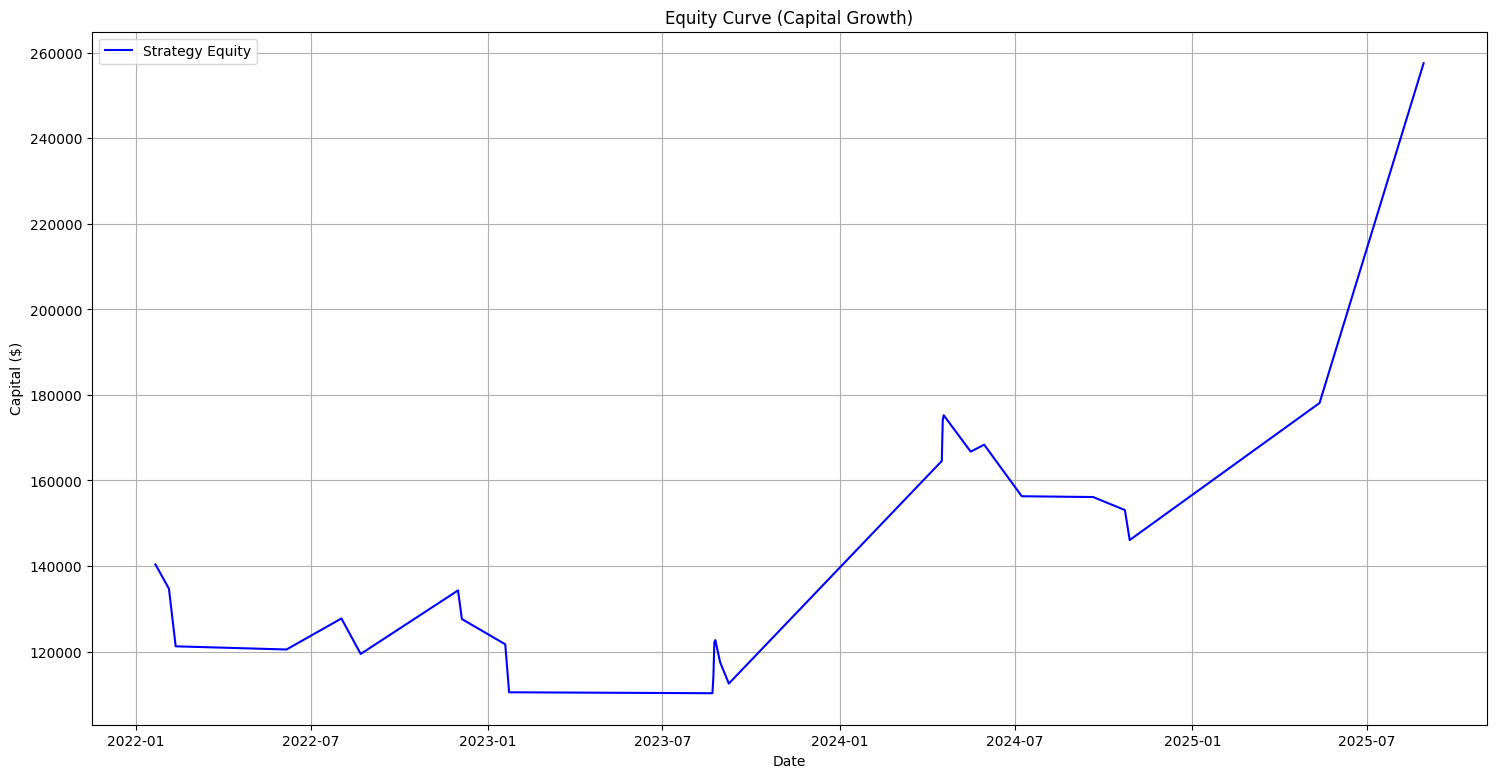

In [ ]:
plt.figure(figsize=(18,9))
plt.plot(trade_log_df["Exit Date"], trade_log_df["Capital"], label="Strategy Equity", color="blue")
plt.title("Equity Curve (Capital Growth)")
plt.xlabel("Date")
plt.ylabel("Capital ($)")
plt.legend()
plt.grid(True)
plt.show()


## 2. Drawdown Curve
A drawdown curve shows the percentage decline from the previous equity peak, helping measure the risk and volatility of a trading strategy. It highlights how much capital was lost during unfavorable periods before recovering.

Inferences from our graph:
1. The strategy experienced multiple drawdowns, with the deepest reaching around -21% in early-mid 2023.

2. The long and deep drawdown in 2024 indicates a challenging phase with significant capital erosion.

3. Frequent drawdowns suggest the strategy may be volatile and could benefit from better risk control or which include adding stop-loss and not going all-in everytime :p

**Thus, we conclude that the strategy has strong recovery ability, but the severity of drawdowns highlights exposure to high downside risk. The strategy may be psychologically dificult to fit in during long drawdowns.**

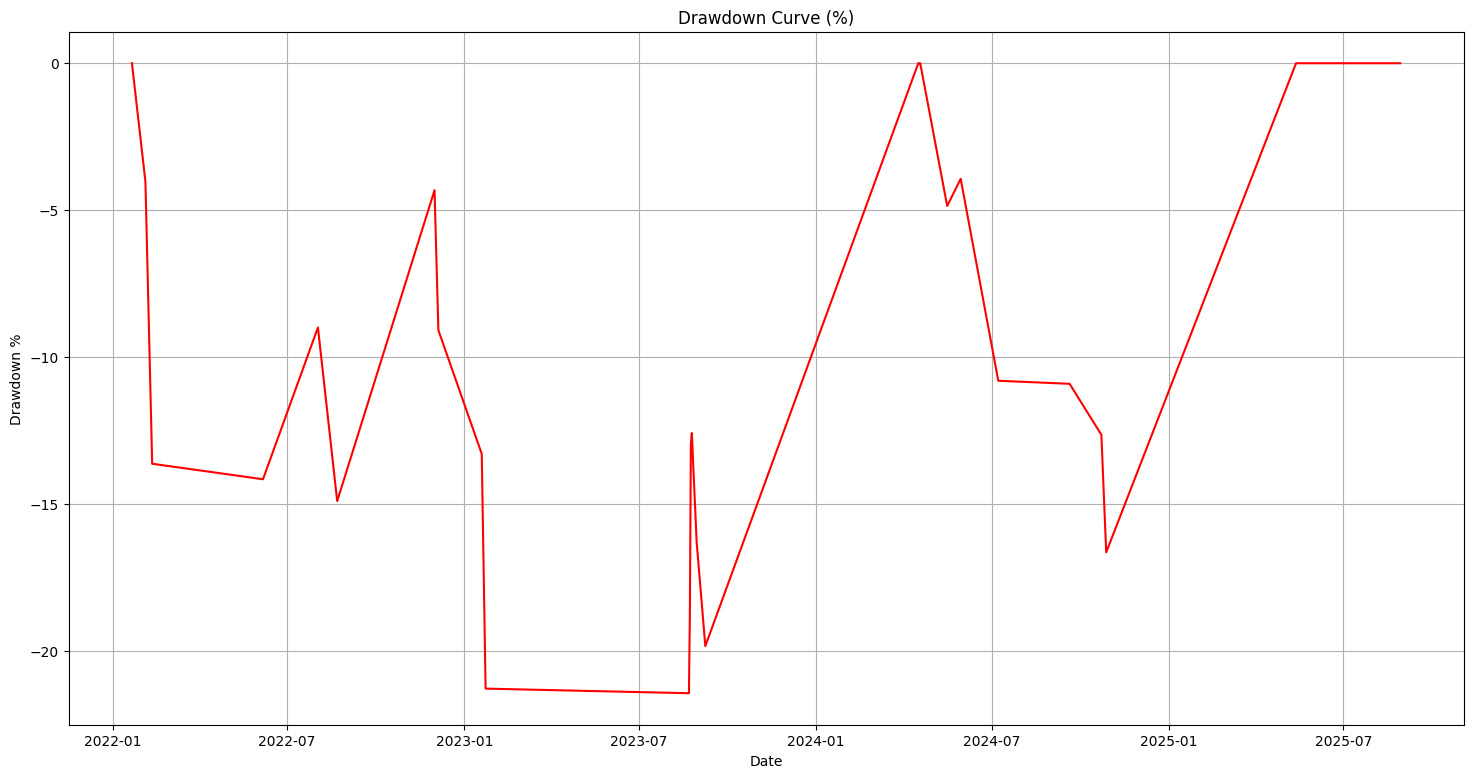

In [ ]:
capital_series = trade_log_df.set_index("Exit Date")["Capital"]
rolling_max = capital_series.cummax()
drawdown = (capital_series - rolling_max) / rolling_max * 100

plt.figure(figsize=(18,9))
plt.plot(drawdown.index, drawdown, color="red")
plt.title("Drawdown Curve (%)")
plt.xlabel("Date")
plt.ylabel("Drawdown %")
plt.grid(True)
plt.show()

## 3. PnL Per Trade
The PnL per trade bar chart is helpful in measuring the types of trades our model made and the frequency of small loss-making trades (due to whipslashes), which can highlight the strategy’s robustness, risk profile, and tendency to cut losses quickly. It also helps in identifying whether profits are driven by a few large winners or by consistent smaller gains, thereby providing insights into the overall reliability and sustainability of the trading model.

Inferences from our graph:
1. The strategy has a few very large winners (trades 1, 13, 21, 32, 33), which contribute significantly to overall profitability.

2. There are many small to moderate losing trades, consistent with a whipsaw effect where trades get stopped out.

3. The winning trades appear less frequent but high in magnitude, suggesting the strategy relies on trend-following behavior—small losses are accepted until a big trend is captured.

4. Despite frequent losses, the large winners outweigh them, which explains the upward-sloping equity curve you showed earlier.

5. The presence of some clusters of red bars shows phases of market conditions where the model struggled.

**Thus, we can conclude that this PnL distribution reflects a strategy that follows the principle of “cut losses short, let winners run.” While the high dependency on big trades makes it volatile, the overall profitability is maintained by capturing the few large trends which the strategy successfully captures and takes into account.**


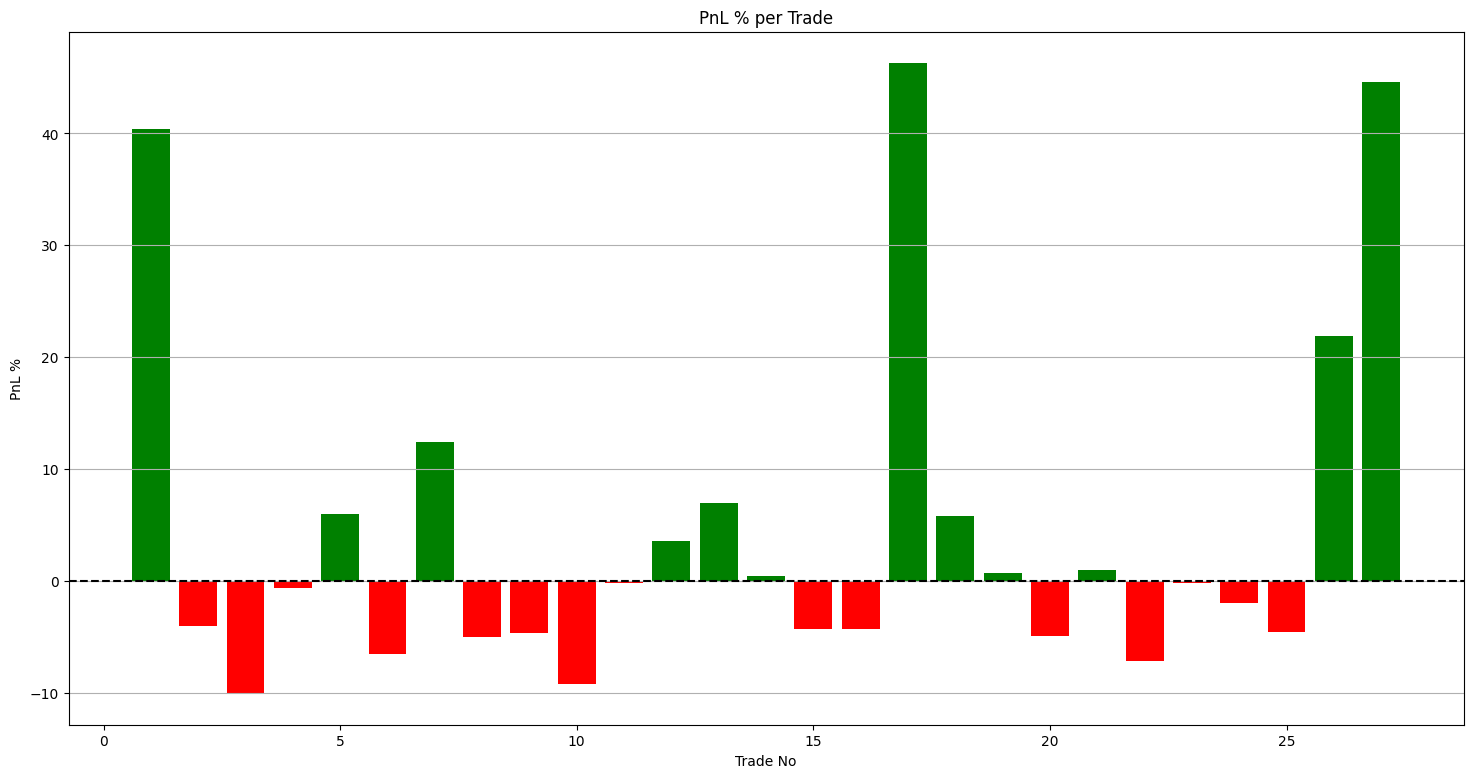

In [ ]:
plt.figure(figsize=(18,9))
colors = ["green" if x > 0 else "red" for x in trade_log_df["PnL %"]]
plt.bar(trade_log_df["Trade No"], trade_log_df["PnL %"], color=colors)
plt.axhline(0, color="black", linestyle="--")
plt.title("PnL % per Trade")
plt.xlabel("Trade No")
plt.ylabel("PnL %")
plt.grid(axis="y")
plt.show()

## 4. Cumulative Returns vs Benchmark (S&P 500)
A Cumulative Returns vs S&P 500 graph compares the performance of a trading strategy against the benchmark index over time. It helps evaluate whether the strategy is able to generate alpha (excess returns) beyond what could be earned by simply investing in the index.

Inferences from our graph:

1. The blue line (Strategy) shows that our model mostly outperformed the yellow line (S&P 500 benchmark) over the test period. There were times where it underperformed but successfully captured the big trades to recover.

2. While the S&P 500 had steady but moderate growth, our strategy showed sharper upward moves as well as downward moves (suggesting periods of strong gains).

3. However, the strategy also had steeper drawdowns, indicating higher volatility compared to the benchmark.

**Overall, our strategy generated higher cumulative returns than simply investing in the S&P 500, which highlights strong alpha generation (alpha wrt. S&P 500)**

/tmp/ipython-input-3561232821.py:2: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed


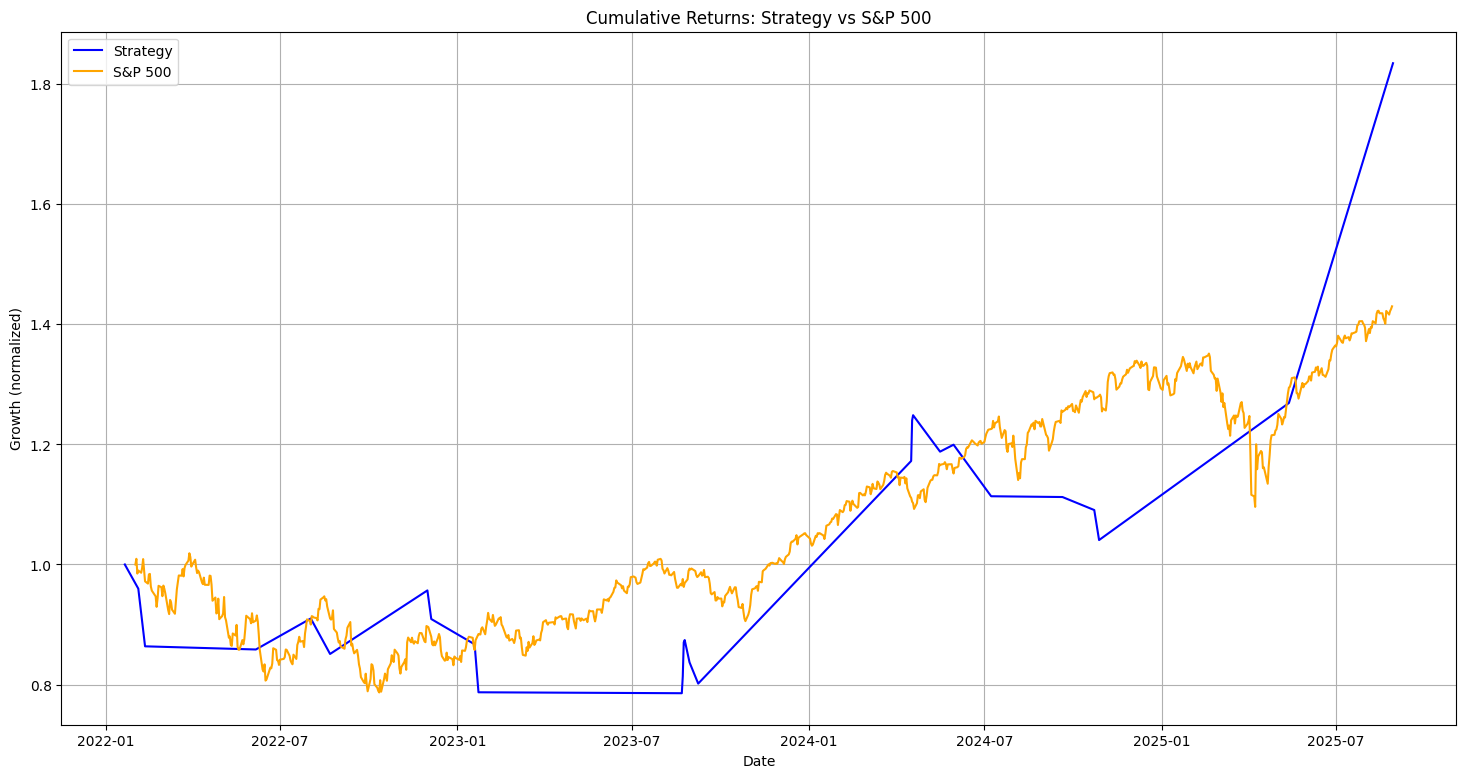

In [ ]:
#downloading S&P 500 data for same period
sp500 = yf.download("^GSPC", start="2022-02-01", end=end_date)

#normalizing strategy and S&P 500 for cumulative returns comparison
strategy_returns = trade_log_df.set_index("Exit Date")["Capital"]
strategy_cumulative = strategy_returns / strategy_returns.iloc[0]

sp500_cumulative = sp500["Close"] / sp500["Close"].iloc[0]

#plotting cumulative returns
plt.figure(figsize=(18, 9))
plt.plot(strategy_cumulative.index, strategy_cumulative.values, label="Strategy", color="blue")
plt.plot(sp500_cumulative.index, sp500_cumulative.values, label="S&P 500", color="orange")
plt.title("Cumulative Returns: Strategy vs S&P 500")
plt.xlabel("Date")
plt.ylabel("Growth (normalized)")
plt.legend()
plt.grid(True)
plt.show()

## 5. Risk/Reward Scatter (Holding Period vs PnL %)
A Risk/Reward Scatter Plot (Holding Period vs PnL %) visualizes the relationship between how long trades are held and the profits or losses they generate. Each point represents a trade, with the x-axis showing the holding period (risk exposure in time) and the y-axis showing the trade’s PnL % (reward or loss).

Inferences from our graph:

1. The scatter shows the distribution of trades based on how long they were held (x-axis) and their profit/loss % (y-axis).

2. Red dots (losses) are clustered in short holding periods, indicating that quick trades often led to small but frequent losses (likely due to whipsaws or noise).

3. Green dots (profits) are more spread out, with larger gains coming from longer holding periods (50–200+ days).

4. This suggests your strategy relies on capturing bigger trends by holding positions longer, while short-term trades carry more risk and incur us losses.

**In essence: “Patience pays off in this strategy, while short-term entries are more prone to failure.”**


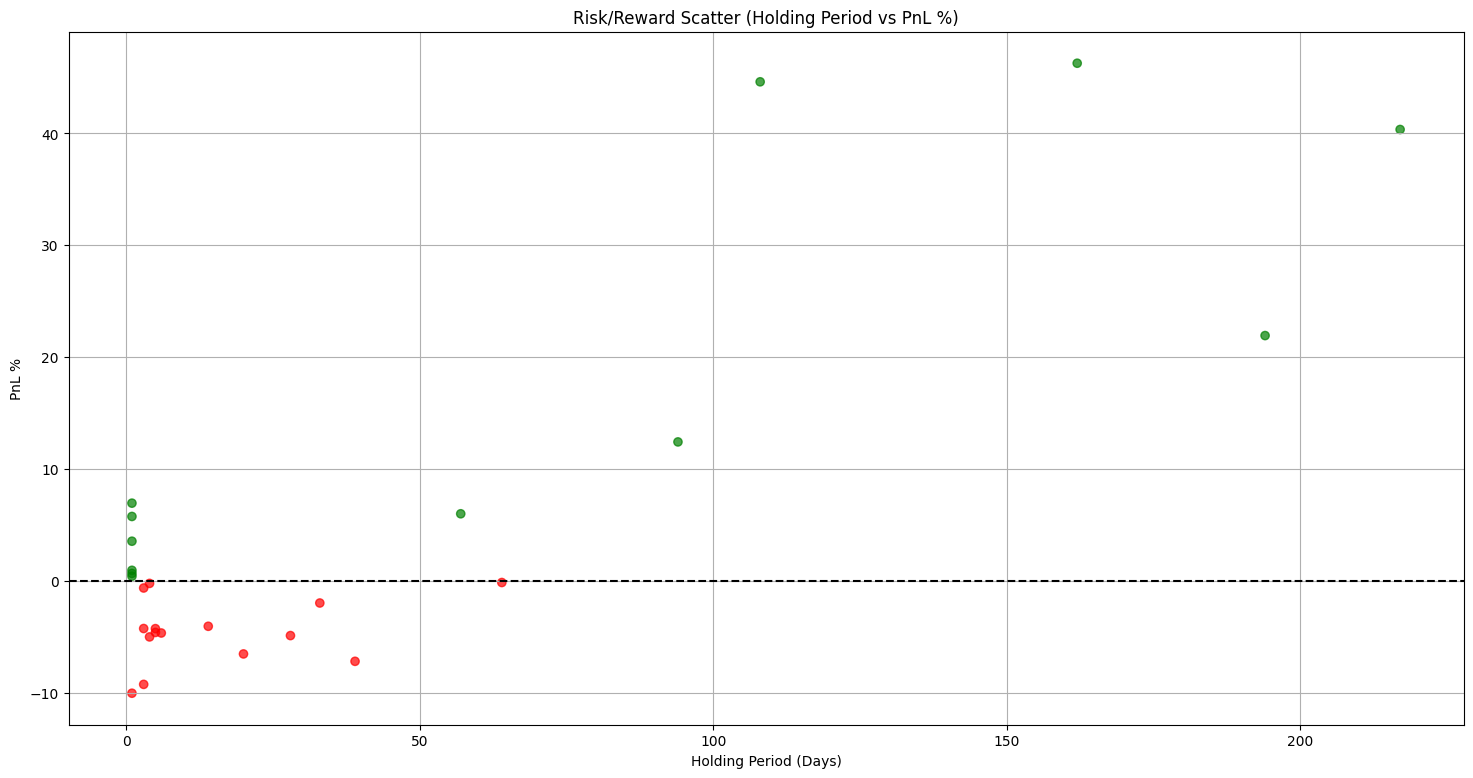

In [ ]:
holding_periods = (pd.to_datetime(trade_log_df["Exit Date"]) - pd.to_datetime(trade_log_df["Entry Date"])).dt.days
plt.figure(figsize=(18,9))
plt.scatter(holding_periods, trade_log_df["PnL %"], c=["green" if x > 0 else "red" for x in trade_log_df["PnL %"]], alpha=0.7)
plt.title("Risk/Reward Scatter (Holding Period vs PnL %)")
plt.xlabel("Holding Period (Days)")
plt.ylabel("PnL %")
plt.axhline(0, color="black", linestyle="--")
plt.grid(True)
plt.show()

## 6. Win/Loss Pie Chart
The win/loss pie chart provides a snapshot of the proportion of profitable vs. losing trades made by the strategy. While the absolute number of winning trades is important, the chart also highlights whether the strategy depends on a higher win rate or on fewer but larger winning trades. For example, here, our winning trades and loosing trades are comparable in number. This visualization makes it easy to understand the balance between consistency and payoff asymmetry in the trading system.

Inferences from our graph:
1. The key inference is that the system likely relies on a small number of large winning trades and some medium winning trades to outweigh the frequent but smaller losses.
2. This aligns with strategies that cut losses quickly while allowing profits to run, leading to a medium win-rate but high reward-to-risk ratio.
3. It also indicates that the strategy’s success is dependent on capturing big and medium trending moves, rather than consistently winning small trades.


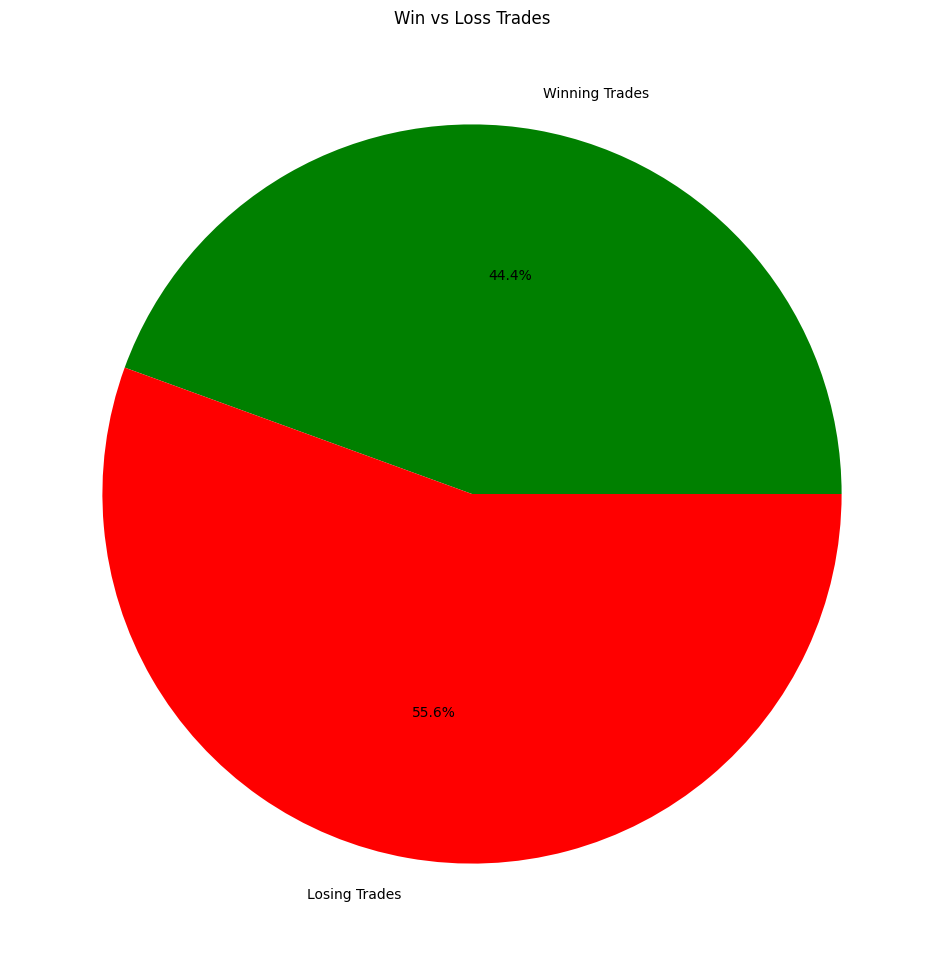

In [ ]:
wins = (trade_log_df["PnL %"] > 0).sum()
losses = (trade_log_df["PnL %"] <= 0).sum()

plt.figure(figsize=(12,12))
plt.pie([wins, losses], labels=["Winning Trades", "Losing Trades"], autopct="%1.1f%%",colors=["green", "red"])
plt.title("Win vs Loss Trades")
plt.show()

## **Common inferences from all Graphs**

1. Our strategy is a medium-risk, high-reward system that relies on a few big and medium size winners to offset many small losses.

2. Superior performance compared to both AMD and the S&P 500 in terms of CAGR and total returns.

3. Weak risk-adjusted return (Sharpe 0.50) indicates that the strategy produces good absolute returns but takes too much volatility.

4. The good win rate (~46%) highlights dependence on long-term holding as well as medium term holding for success.

5. Drawdowns are medium (~21%), meaning investors need medium-high risk tolerance and position sizing mechanisms.

**The system is more suited for investors comfortable with volatility and long-term holding horizons, rather than short-term traders. The model is PROFITABLE BUT VOLATILE (since we used only simple moving average).**

# Justifications and FAQ's
1. **Why AMD?**- I was looking for a stock which underwent a big bullish as well as a big bearish movement in the timeframe. This is the essence of SIMPLE MOVING AVERAGE STRATEGY. It performs better in bearish markets and can easily capture long-term behaviours (bullish or bearish) of a particular stock.

2. **Why 100D Moving average?**- I ran the code with different time windows. These were the results and conclusions:
Conclusion: 100-day MA is the best — highest Sharpe, highest PnL, and strong alpha, with a manageable drawdown compared to others.But, If we prioritize lower drawdowns over absolute returns, 50-day MA could be a safer choice (less volatile, decent Sharpe), but we sacrifice returns.
| MA Window | %PnL   |  Sharpe | Max Drawdown | Alpha  |
| --------- | ------ |  ------ | ------------ | ------ |
| 20        | 64.21  |  0.41   | -54.84       | -3.02  |
| 50        | 95.24  |  0.33   | -49.99       | -1.34  |
| 100       | 157.57 |  0.50   | -21.45       |  7.45  |
| 150       | 42.64  |  0.27   | -25.87       | -1.91  |
| 200       | -7.20  | -0.14   | -31.78       | -16.11 |
| 300       | 15.21  |  0.04   | -19.77       | -3.84  |
200D is obviously very bad.
%Pnl: Best is 100D (157.57%)
Sharpe: Best is 100D (0.50)
Max Drawdown: Best is 300D
***Thus we can conclude that 100D is the best MA window because of high profit, relatively high sharpee and lower max drawdown.***

3. **Why stop-loss implemented?**- The model was making huge losses before implementing stop loss (still profitable :p) but after implementing stop loss, it was able to efficiently cut down losses incurred and generate bigger profits in the same time-frame.

4. **Why did the model still make 10% loss in a trade even after stop loss?**-because the model operates on close prices of a day and if the prices fell by 10% in a single day, the model can't implement stop loss before because we are not trading intraday but on closing prices of every day. If the model had no stop-loss, we would have made greater loss in that trade. The big loss trade is speculated to be due to Nvidia's stock pumping and their new tech launching in the same time period. And since AMD is a direct competitor to NVIDIA (in GPU market), a panic set up caused it's stock to fall rapidly.

4. **Why low sharpe ratio?** - We only used a single trading strategy here (Simple Moving Average). A single naive strategy is expected to produce a sharpe of ~0.3 (such as RSI, SMA etc.) but our model having 0.5 denotes that our strategy has a real edge and not just noise. Also, we haven't taken into account the transaction costs yet. They will lower the sharpe as it is a necessary additional cost incurred by the model while trading. So, we can expect the sharpe to fall to ~(0.40-0.45) in real life.
